In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
from google.colab import files
uploaded=files.upload()
df=pd.read_csv('diabetes1.csv')


Saving diabetes1.csv to diabetes1.csv


In [5]:
df.describe()
df.shape
df.info()
df.isnull().sum()
df=df.dropna()
df.shape
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             543 non-null    float64
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0


In [6]:
df['Insulin'].value_counts()
mean_value=df['Insulin'].mean()
print(mean_value)


118.10313075506446


In [7]:
df['Insulin']=df['Insulin'].replace(0,mean_value)
df['Insulin'].value_counts()

,count
Insulin,
118.103131,77
105.000000,11
100.000000,9
140.000000,9
130.000000,9
...,...
510.000000,1
16.000000,1
350.000000,1


<Axes: >

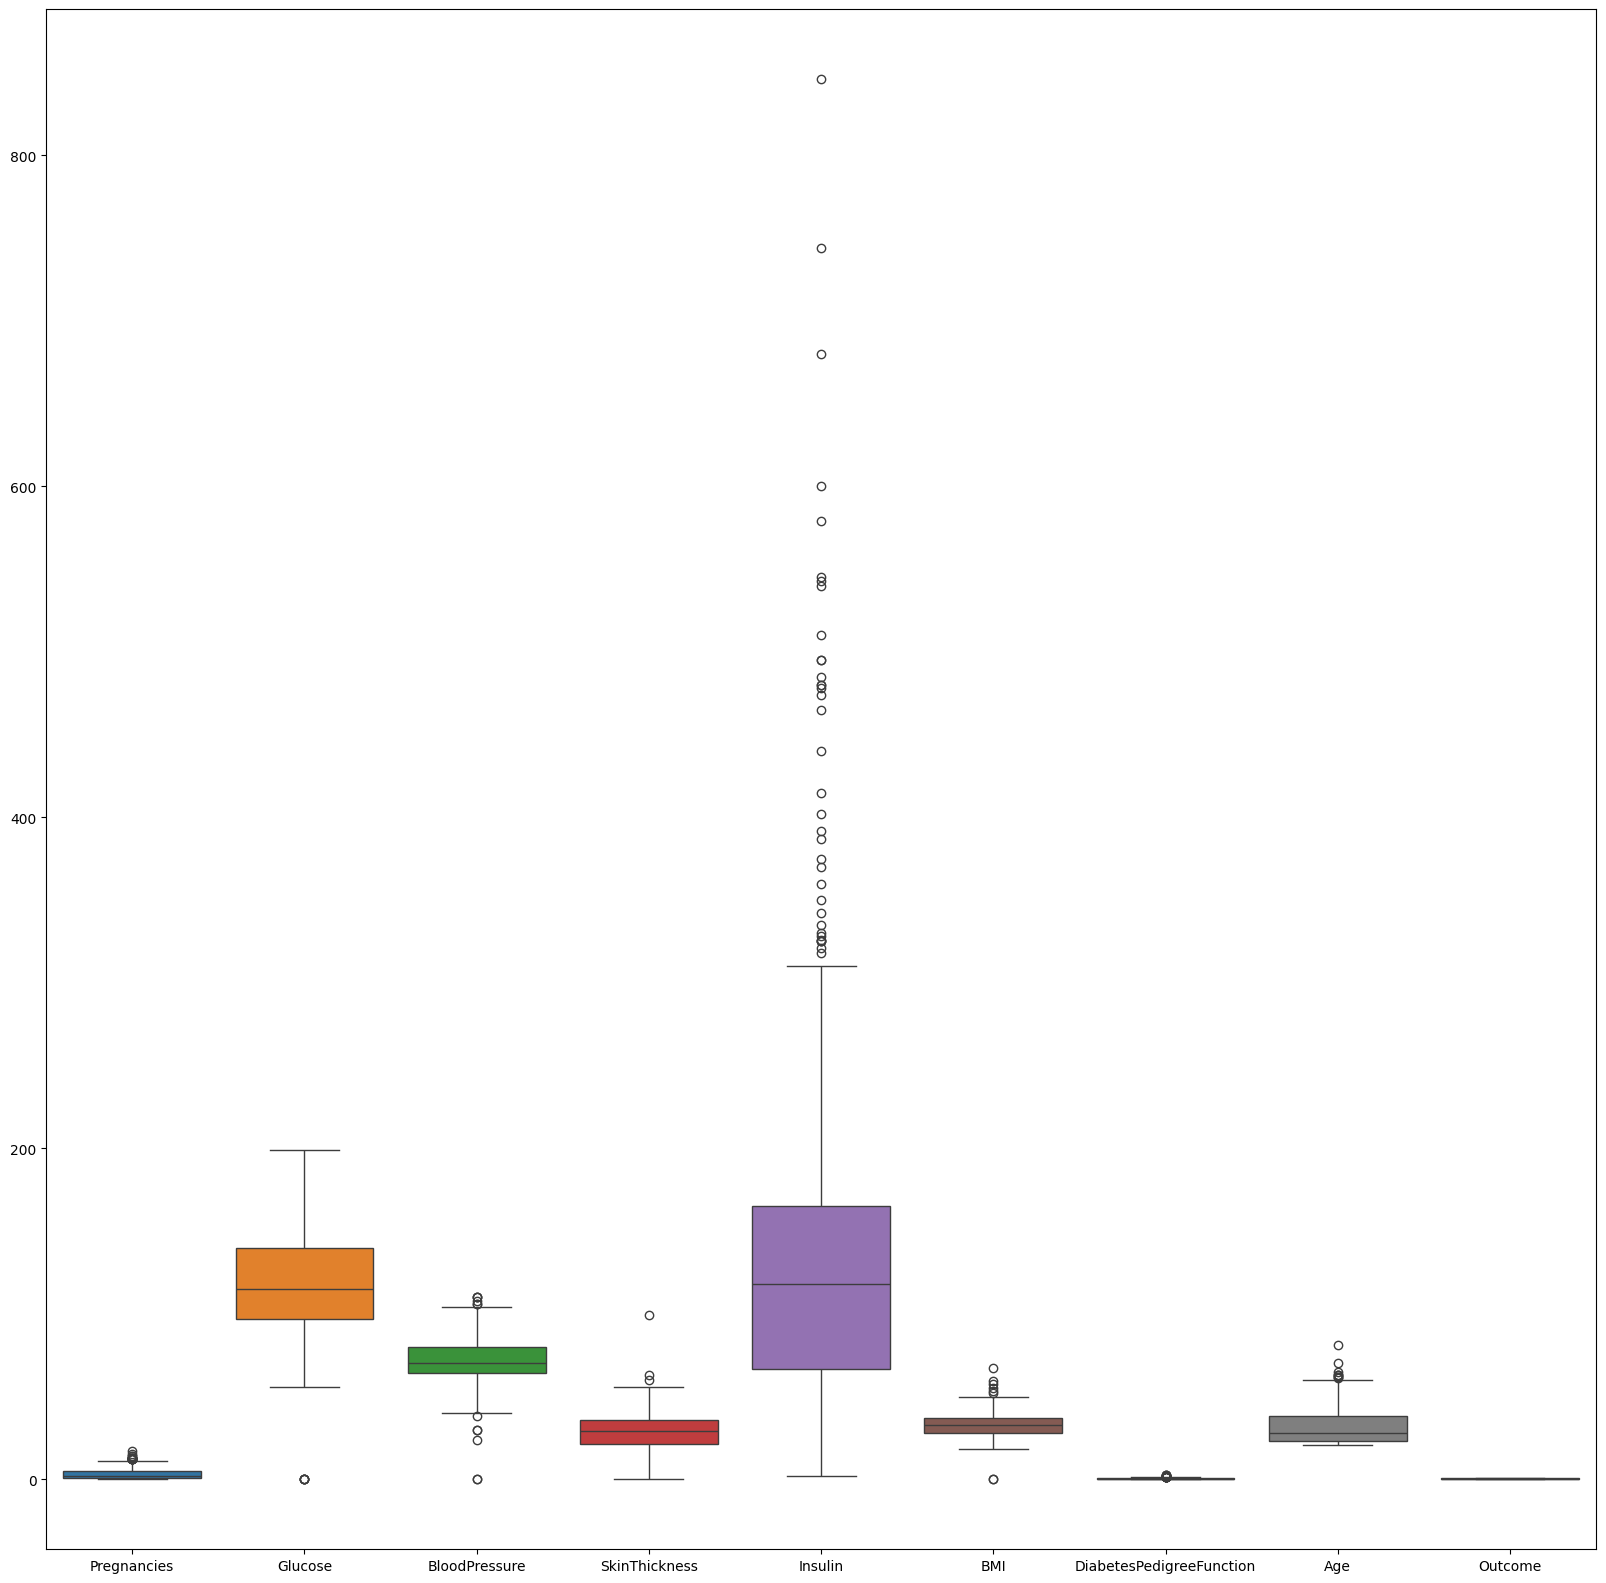

In [8]:
fig, ax = plt.subplots(figsize=(20,20))
sns.boxplot(data=df,ax=ax)

<Axes: xlabel='Pregnancies'>

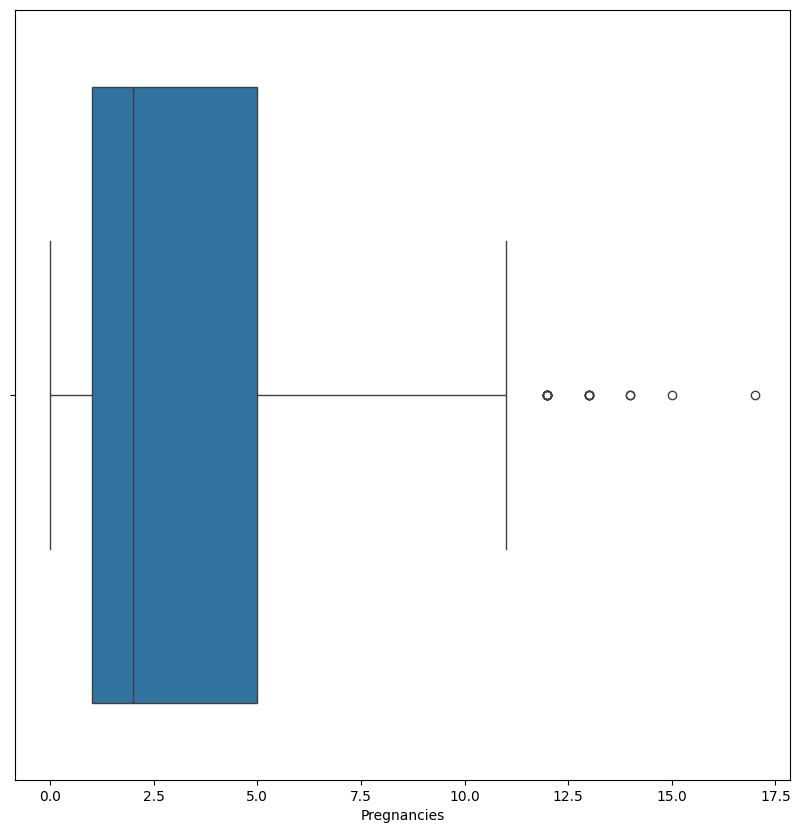

In [9]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=df['Pregnancies'],ax=ax)

In [10]:
q1=df['Pregnancies'].quantile(0.25)
q3=df['Pregnancies'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data=df[(df['Pregnancies']>lower_bound)&(df['Pregnancies']<upper_bound)]
print(new_data)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
4              0      137             40           35.0    168.0  43.1   
6              3       78             50           32.0     88.0  31.0   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='Pregnancies'>

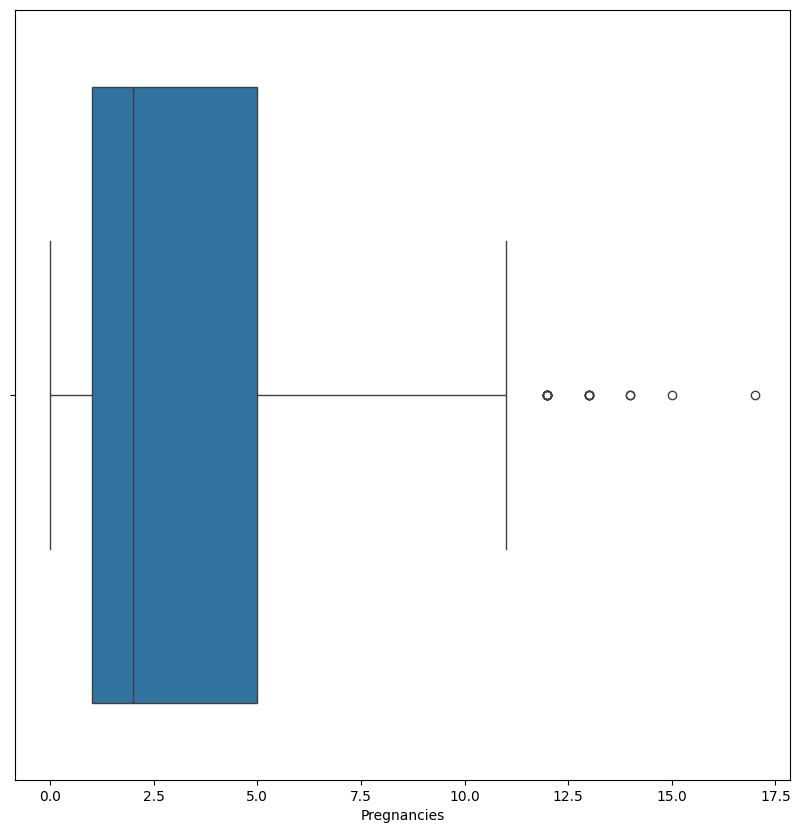

In [11]:
fig, ax = plt.subplots(figsize=(10,10))
sns.boxplot(x=df['Pregnancies'],ax=ax)

<Axes: xlabel='Glucose'>

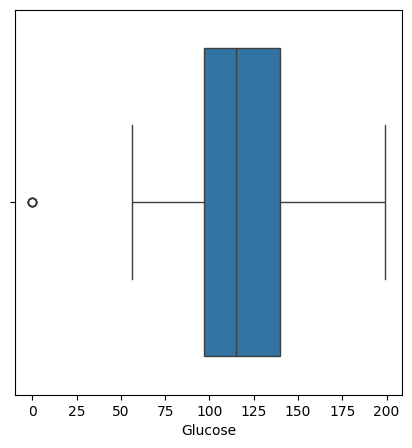

In [12]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['Glucose'],ax=ax)

In [13]:
q1=new_data['Glucose'].quantile(0.25)
q3=new_data['Glucose'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data1=new_data[(new_data['Glucose']>=lower_bound)&(new_data['Glucose']<=upper_bound)]
print(new_data1)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
4              0      137             40           35.0    168.0  43.1   
6              3       78             50           32.0     88.0  31.0   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='Glucose'>

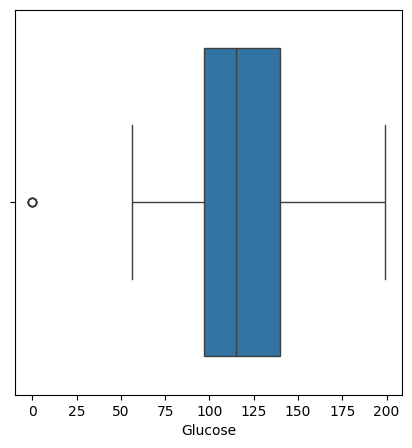

In [14]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['Glucose'],ax=ax)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
4              0      137             40           35.0    168.0  43.1   
6              3       78             50           32.0     88.0  31.0   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

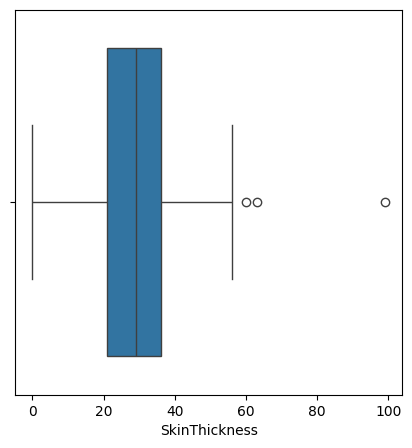

In [16]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data1['SkinThickness'],ax=ax)
q1=new_data1['SkinThickness'].quantile(0.25)
q3=new_data1['SkinThickness'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data2=new_data1[(new_data1['SkinThickness']>=lower_bound)&(new_data1['SkinThickness']<=upper_bound)]
print(new_data2)

<Axes: xlabel='SkinThickness'>

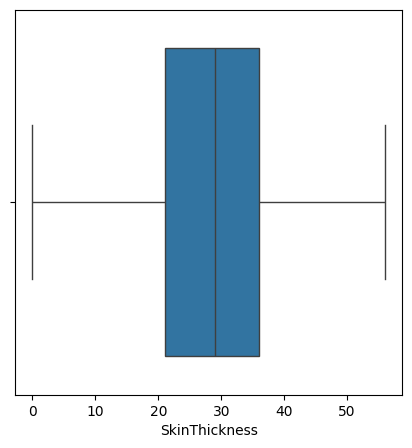

In [17]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data2['SkinThickness'],ax=ax)

<Axes: xlabel='Insulin'>

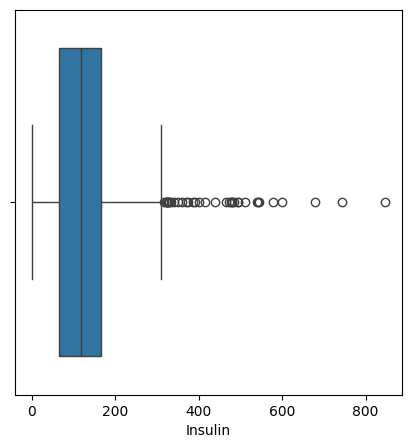

In [18]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['Insulin'],ax=ax)

In [19]:
q1=new_data2['Insulin'].quantile(0.25)
q3=new_data2['Insulin'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data3=new_data2[(new_data2['Insulin']>=lower_bound)&(new_data2['Insulin']<=upper_bound)]
print(new_data3)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
4              0      137             40           35.0    168.0  43.1   
6              3       78             50           32.0     88.0  31.0   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='Insulin'>

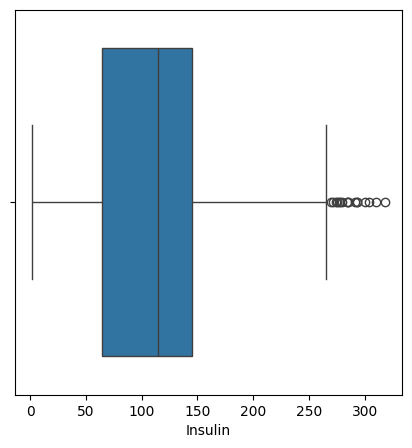

In [20]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data3['Insulin'],ax=ax)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
6              3       78             50           32.0     88.0  31.0   
14             5      166             72           19.0    175.0  25.8   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='BloodPressure'>

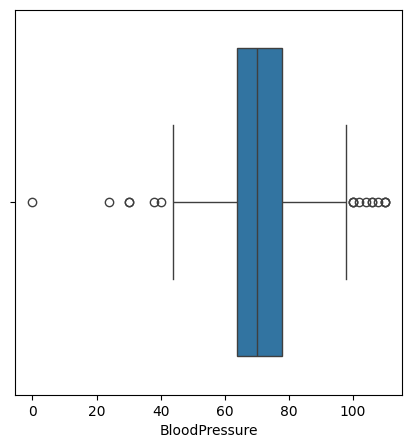

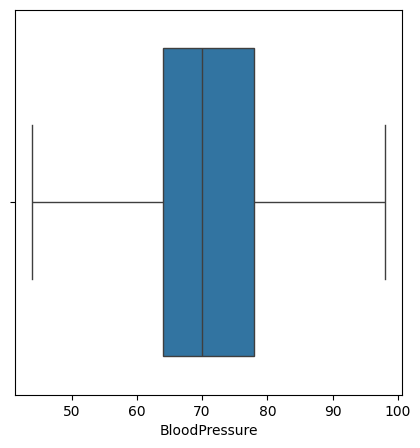

In [21]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data3['BloodPressure'],ax=ax)
q1=new_data3['BloodPressure'].quantile(0.25)
q3=new_data3['BloodPressure'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data4=new_data3[(new_data3['BloodPressure']>=lower_bound)&(new_data3['BloodPressure']<=upper_bound)]
print(new_data4)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data4['BloodPressure'],ax=ax)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
6              3       78             50           32.0     88.0  31.0   
14             5      166             72           19.0    175.0  25.8   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='BMI'>

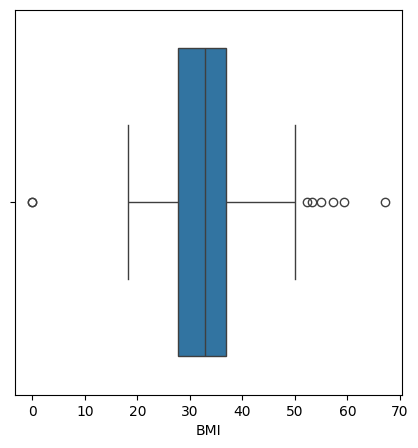

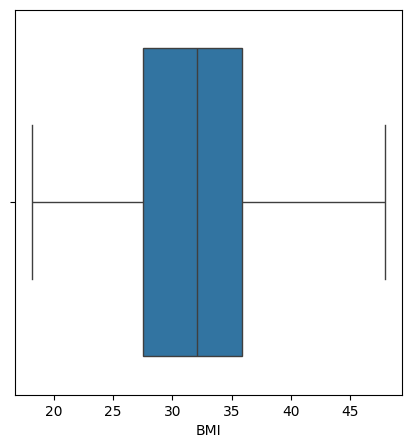

In [22]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['BMI'],ax=ax)
q1=new_data4['BMI'].quantile(0.25)
q3=new_data4['BMI'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data5=new_data4[(new_data4['BMI']>lower_bound)&(new_data4['BMI']<upper_bound)]
print(new_data5)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data5['BMI'],ax=ax)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
6              3       78             50           32.0     88.0  31.0   
14             5      166             72           19.0    175.0  25.8   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76           48.0    180.0  32.9   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='DiabetesPedigreeFunction'>

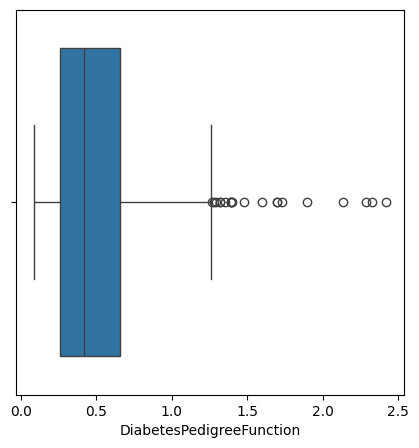

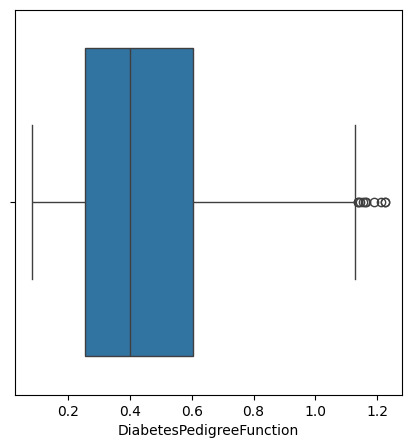

In [23]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=df['DiabetesPedigreeFunction'],ax=ax)
q1=new_data5['DiabetesPedigreeFunction'].quantile(0.25)
q3=new_data5['DiabetesPedigreeFunction'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data6=new_data5[(new_data5['DiabetesPedigreeFunction']>lower_bound)&(new_data5['DiabetesPedigreeFunction']<upper_bound)]
print(new_data6)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data6['DiabetesPedigreeFunction'],ax=ax)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
6              3       78             50           32.0     88.0  31.0   
14             5      166             72           19.0    175.0  25.8   
..           ...      ...            ...            ...      ...   ...   
762            9       89             62            0.0    100.0  22.5   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  Outcome  
0                       0.627   50        1  
1                  

<Axes: xlabel='Age'>

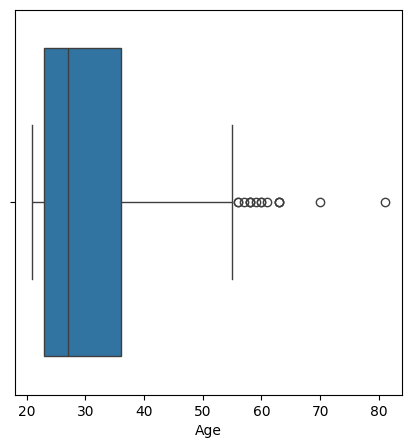

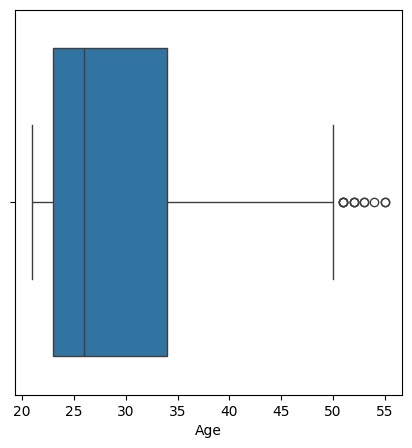

In [24]:
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data6['Age'],ax=ax)
q1=new_data6['Age'].quantile(0.25)
q3=new_data6['Age'].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
new_data7=new_data6[(new_data6['Age']>lower_bound)&(new_data6['Age']<upper_bound)]
print(new_data7)
fig, ax = plt.subplots(figsize=(5,5))
sns.boxplot(x=new_data7['Age'],ax=ax)

<Axes: >

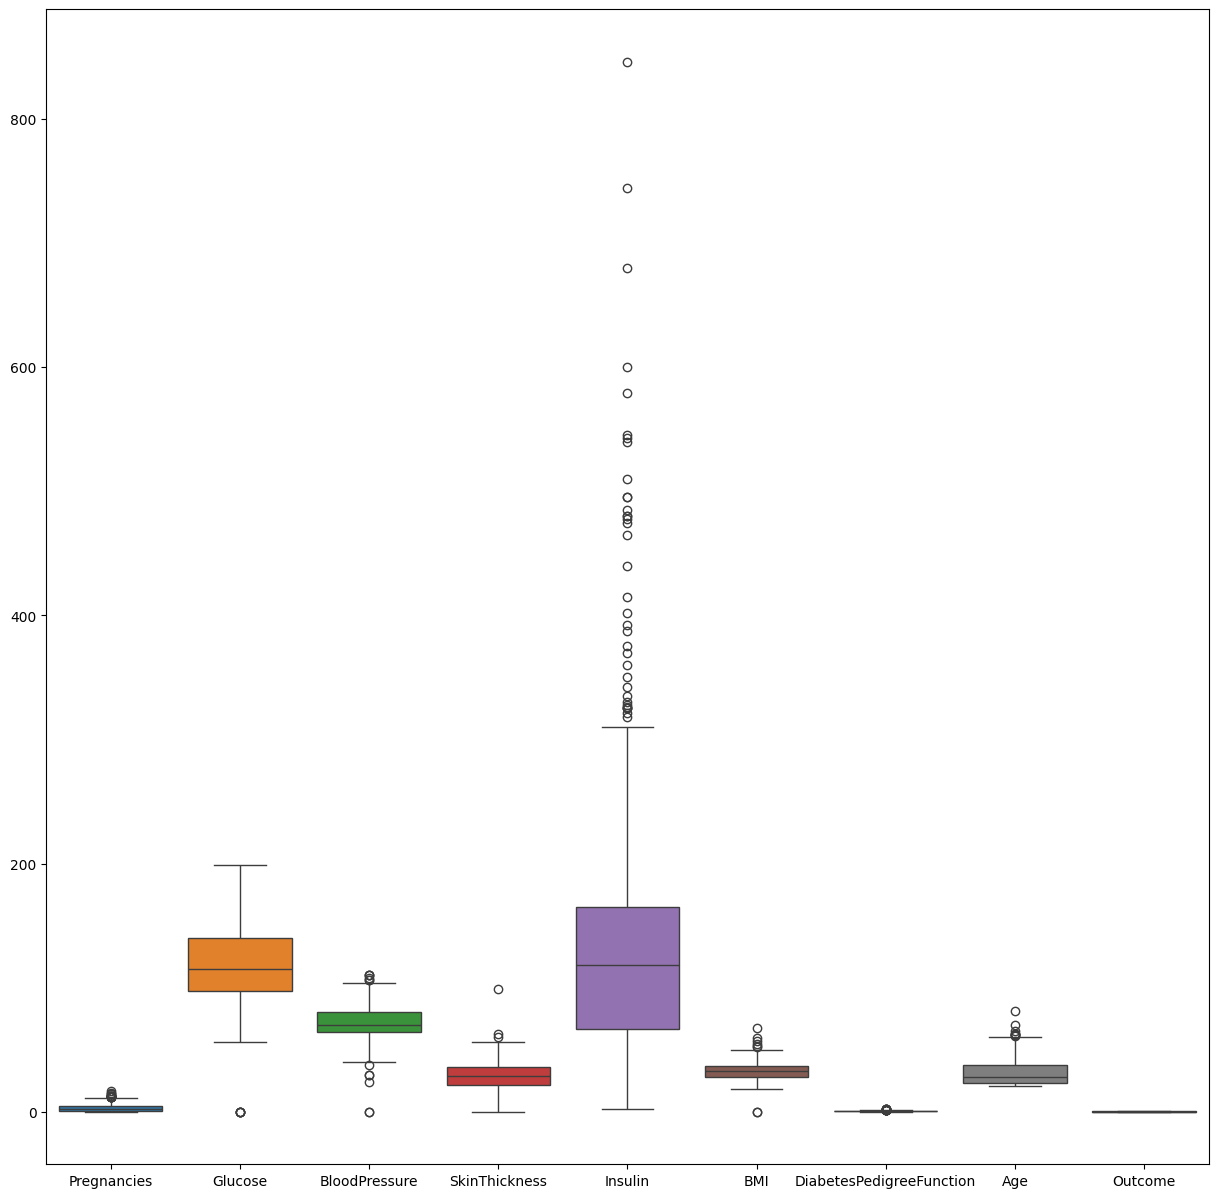

In [25]:
fig, ax = plt.subplots(figsize=(15,15))
sns.boxplot(data=df,ax=ax)

In [26]:
correlation=new_data7.corr()
correlation

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.141994,0.160710,0.110484,0.012640,0.003371,0.073325,0.645528,0.240800
Glucose,0.141994,1.000000,0.212771,0.154463,0.483680,0.213138,0.135903,0.291248,0.505455
BloodPressure,0.160710,0.212771,1.000000,0.225399,0.095105,0.310152,0.064540,0.313292,0.167219
SkinThickness,0.110484,0.154463,0.225399,1.000000,0.167364,0.659596,0.066912,0.157075,0.198891
Insulin,0.012640,0.483680,0.095105,0.167364,1.000000,0.266528,0.149426,0.152910,0.271377
BMI,0.003371,0.213138,0.310152,0.659596,0.266528,1.000000,0.141985,0.127937,0.253597
DiabetesPedigreeFunction,0.073325,0.135903,0.064540,0.066912,0.149426,0.141985,1.000000,0.175257,0.262173
Age,0.645528,0.291248,0.313292,0.157075,0.152910,0.127937,0.175257,1.000000,0.368147
Outcome,0.240800,0.505455,0.167219,0.198891,0.271377,0.253597,0.262173,0.368147,1.000000


<Axes: >

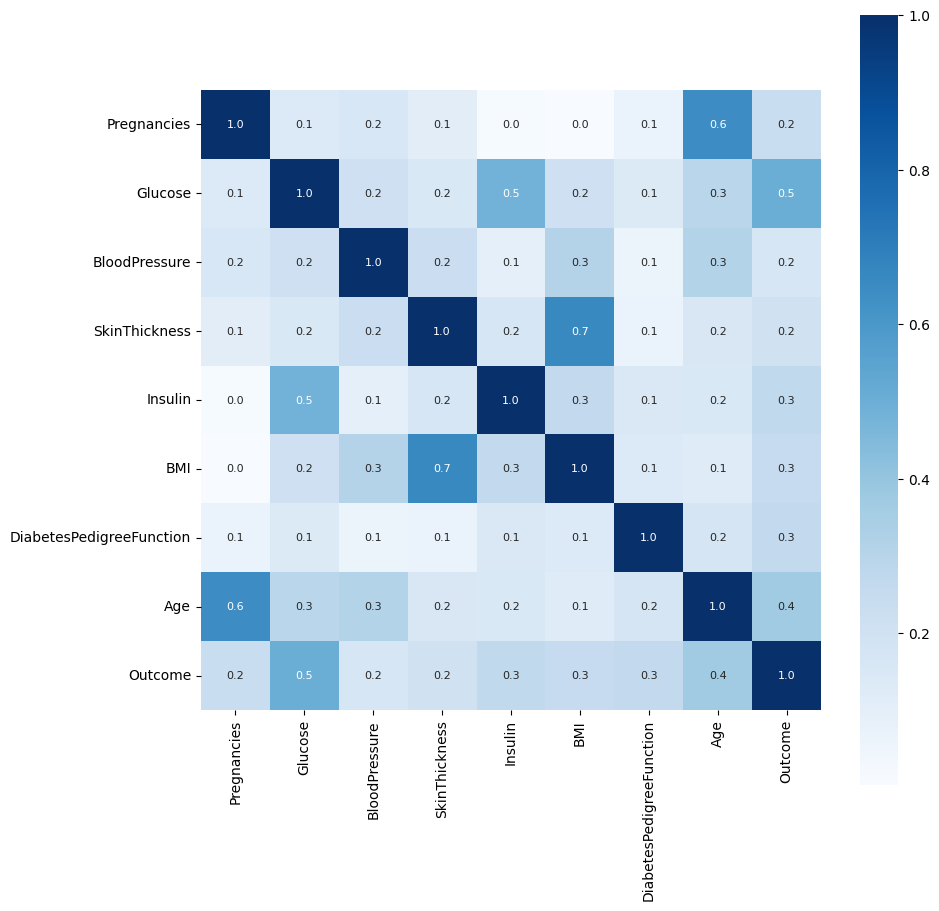

In [27]:
plt.figure(figsize=(10,10))
sns.heatmap(correlation,cbar=True,square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Blues')

In [28]:
cleaned_data=new_data7['Outcome'].value_counts()
print(cleaned_data)

Outcome
0    307
1    115
Name: count, dtype: int64


In [29]:
x=new_data7.drop(columns='Outcome',axis=1)
y=new_data7['Outcome']
print(x)
print(y)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72           35.0    100.0  33.6   
1              1       85             66           29.0     25.0  26.6   
3              1       89             66           23.0     94.0  28.1   
6              3       78             50           32.0     88.0  31.0   
14             5      166             72           19.0    175.0  25.8   
..           ...      ...            ...            ...      ...   ...   
762            9       89             62            0.0    100.0  22.5   
764            2      122             70           27.0     80.0  36.8   
765            5      121             72           23.0    112.0  26.2   
766            1      126             60            0.0    180.0  30.1   
767            1       93             70           31.0     90.0  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


In [30]:
from imblearn.over_sampling import SMOTE
smote=SMOTE()
x_resampled,y_resampled=smote.fit_resample(x,y)
x_train,x_test,y_train,y_test=train_test_split(x_resampled,y_resampled,test_size=0.3,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape,y_resampled.shape,x_resampled.shape

((429, 8), (185, 8), (429,), (185,), (614,), (614, 8))

In [31]:
model=LogisticRegression()
model.fit(x_train,y_train)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [32]:
training_data_prediction=model.predict(x_train)
training_data_accuracy=accuracy_score(training_data_prediction,y_train)
print(training_data_accuracy)
testing_data_prediction=model.predict(x_test)
testing_data_accuracy=accuracy_score(testing_data_prediction,y_test)
print(testing_data_accuracy)

0.7715617715617715
0.7621621621621621


In [33]:
cm=confusion_matrix(y_test,testing_data_prediction)
print(cm)


[[66 29]
 [15 75]]


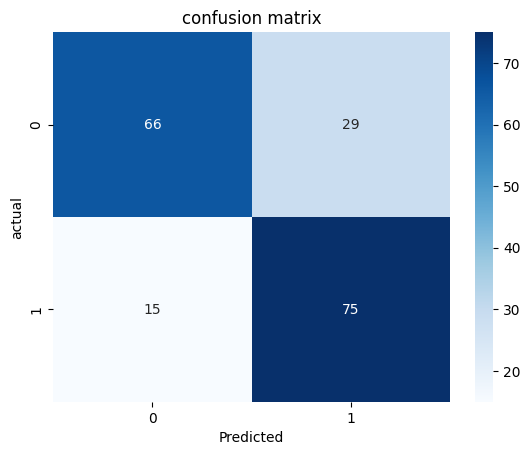

In [34]:
sns.heatmap(cm,annot=True,cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('actual')
plt.title('confusion matrix')
plt.show()

In [35]:
new_data=(8,183,64,0,0,23.3,0.672,32)
new_data_array=np.asarray(new_data)
new_data_reshaped=new_data_array.reshape(1,-1)
prediction=model.predict(new_data_reshaped)
if(prediction[0]==0):
  print('the person is not diabetic')
else:
  print('the person is diabetic')

the person is diabetic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
